In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import joblib

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, make_scorer, cohen_kappa_score
from sklearn import tree
from sklearn.model_selection import train_test_split, LeaveOneOut, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from pypalettes import load_cmap
import matplotlib.pyplot as plt
import statsmodels.api as sm

cmap = load_cmap("Green_Orange_Teal")
noir ="#131d12"
plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['font.weight'] = 'normal'

# import data

In [2]:
df_data_base = pd.read_csv("data/Sondage/data-base.csv")
df_data_personnes = pd.read_csv("data/Sondage/data-personnes.csv")
df_data_photos = pd.read_csv("data/Sondage/data-photos.csv")
df_merged = pd.merge(df_data_base, df_data_photos, on="id_photo")
df_merged = pd.merge(df_merged, df_data_personnes, on="id_personne")
df_mean = pd.read_csv("data/Sondage/sumary.csv")
df_mean['Note (moyenne)'] = df_mean['Note (moyenne)'].str.replace(',', '.').astype(float)
df_mean = df_mean[['Voies', 'Vitesse', 'Pente', 'Green','Type', 'Note (moyenne)']]
df_mean.columns = ['nbr_lane', 'speed', 'slope', 'green','type', 'note']

# Linear regression

## 1 - data traitement

In [3]:
y_mean = df_mean['note']
y_mean_rounded = y_mean.round()

X_mean_classified = df_mean[['nbr_lane', 'speed', 'slope', 'green']]
X_mean_type = df_mean[['type']]

enc = OneHotEncoder(handle_unknown='ignore')
X_mean_type_encoded = enc.fit_transform(X_mean_type)

type_encoded_columns = enc.get_feature_names_out(['type'])

X_mean = pd.concat([
    X_mean_classified.reset_index(drop=True),
    pd.DataFrame(X_mean_type_encoded.toarray(), columns=type_encoded_columns).reset_index(drop=True)
], axis=1)

In [4]:
depth = None
random_state = 10

y_all = df_merged['note']

X_classified_df = df_merged[['nbr_lane', 'speed', 'slope', 'green']]
X_type = df_merged[['type']]

enc = OneHotEncoder(handle_unknown='ignore')
X_type_encoded = enc.fit_transform(X_type)

type_encoded_columns = enc.get_feature_names_out(['type'])

X_all_df = pd.concat([
    X_classified_df.reset_index(drop=True),
    pd.DataFrame(X_type_encoded.toarray(), columns=type_encoded_columns).reset_index(drop=True)
], axis=1)

## 2 - Mean Linear Regression (linear_mean)

In [78]:
X_mean_train, X_mean_test, y_mean_train, y_mean_test = train_test_split(X_mean, y_mean, test_size=0.2, random_state=42)

linear_mean = LinearRegression()
linear_mean.fit(X_mean_train, y_mean_train)

y_mean_lr_predicted_test = linear_mean.predict(X_mean_test)
y_mean_lr_predicted_train = linear_mean.predict(X_mean_train)

mse_mean_lr_test = mean_squared_error(y_mean_test, y_mean_lr_predicted_test)
mse_mean_lr_train = mean_squared_error(y_mean_train, y_mean_lr_predicted_train)
r2_mean_lr_test = r2_score(y_mean_test, y_mean_lr_predicted_test)
r2_mean_lr_train = r2_score(y_mean_train, y_mean_lr_predicted_train)

coefs_mean_lr = pd.Series(linear_mean.coef_, index=X_mean.columns)
coefs_mean_lr = coefs_mean_lr.sort_values(ascending=False)

print("Linear Regression Mean")
print(f"Train MSE: {mse_mean_lr_train}, R²: {r2_mean_lr_train}")
print(f"Test MSE: {mse_mean_lr_test}, R²: {r2_mean_lr_test}")
print("Coefficients:")
print(coefs_mean_lr)



Linear Regression Mean
Train MSE: 0.01130530299001113, R²: 0.9786877955005556
Test MSE: 0.023950133386852757, R²: 0.9750683506877872
Coefficients:
type_3      0.870935
green       0.339183
type_2      0.000000
speed      -0.041709
slope      -0.076644
nbr_lane   -0.136876
type_1     -0.188650
type_0     -0.682285
dtype: float64


In [79]:
X_mean_c = sm.add_constant(X_mean)
model = sm.OLS(y_mean, X_mean_c).fit()

# Résumé
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   note   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     83.54
Date:                Tue, 12 Aug 2025   Prob (F-statistic):           1.82e-07
Time:                        17:29:31   Log-Likelihood:                 14.906
No. Observations:                  17   AIC:                            -13.81
Df Residuals:                       9   BIC:                            -7.147
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6050      0.079     33.010      0.0

c:\Users\tim3l\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=17
  res = hypotest_fun_out(*samples, **kwds)


## 2 - All Linear Regression (linear_all)

In [80]:
X_train, X_test, Y_train, Y_test = train_test_split(X_all_df, y_all, test_size=0.2, random_state=42)

linear_all = LinearRegression()
linear_all.fit(X_train, Y_train)

y_all_lr_predicted_test = linear_mean.predict(X_test)
y_all_lr_predicted_train = linear_mean.predict(X_train)

mse_all_lr_test = mean_squared_error(Y_test, y_all_lr_predicted_test)
mse_all_lr_train = mean_squared_error(Y_train, y_all_lr_predicted_train)
r2_all_lr_test = r2_score(Y_test, y_all_lr_predicted_test)
r2_all_lr_train = r2_score(Y_train, y_all_lr_predicted_train)


coefs_all_lr = pd.Series(linear_all.coef_, index=X_all_df.columns)
coefs_all_lr = coefs_all_lr.sort_values(ascending=False)

print("Linear Regression all")
print(f"Train MSE: {mse_all_lr_train}, R²: {r2_all_lr_train}")
print(f"Test MSE: {mse_all_lr_test}, R²: {r2_all_lr_test}")
print("Coefficients:")
print(coefs_all_lr)

Linear Regression all
Train MSE: 0.9106132053244503, R²: 0.417326685948166
Test MSE: 0.92364386139802, R²: 0.4117364892546763
Coefficients:
type_3      0.877968
green       0.375897
type_2      0.001635
speed      -0.035133
slope      -0.135970
type_1     -0.179481
nbr_lane   -0.186729
type_0     -0.700122
dtype: float64


In [81]:
X_c = sm.add_constant(X_all_df)
model_2 = sm.OLS(y_all, X_c).fit()

# Résumé
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                   note   R-squared:                       0.420
Model:                            OLS   Adj. R-squared:                  0.419
Method:                 Least Squares   F-statistic:                     385.8
Date:                Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                        17:29:31   Log-Likelihood:                -5128.2
No. Observations:                3740   AIC:                         1.027e+04
Df Residuals:                    3732   BIC:                         1.032e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6113      0.037     71.162      0.0

# Mean tree

## 1 - data traitment

In [5]:
y_mean = df_mean['note']
y_mean_rounded = y_mean.round()

X_mean_classified = df_mean[['nbr_lane', 'speed', 'slope', 'green']]
X_mean_type = df_mean[['type']]

enc = OneHotEncoder(handle_unknown='ignore')
X_mean_type_encoded = enc.fit_transform(X_mean_type)

type_encoded_columns = enc.get_feature_names_out(['type'])

X_mean = pd.concat([
    X_mean_classified.reset_index(drop=True),
    pd.DataFrame(X_mean_type_encoded.toarray(), columns=type_encoded_columns).reset_index(drop=True)
], axis=1)

In [6]:
X_mean.describe()

,nbr_lane,speed,slope,green,type_0,type_1,type_2,type_3
count,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000
mean,0.941176,1.352941,0.529412,0.764706,0.235294,0.352941,0.117647,0.294118
std,1.028992,1.320094,0.717430,0.664211,0.437237,0.492592,0.332106,0.469668
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,3.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000
max,3.000000,3.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
y_mean.describe()

count    17.000000
mean      3.310382
std       0.842986
min       2.027650
25%       2.677419
50%       3.110599
75%       3.995392
max       4.626728
Name: note, dtype: float64

In [8]:
y_mean_rounded.describe()

count    17.000000
mean      3.235294
std       0.903425
min       2.000000
25%       3.000000
50%       3.000000
75%       4.000000
max       5.000000
Name: note, dtype: float64

## 2 - regression mean (regr_mean)

Regression Mean
Train MSE: 0.0, R²: 1.0, mae: 0.0
Test MSE: 0.11976257730795942, R²: 0.8753293549585034, mae: 0.32027649775
Depth: 7


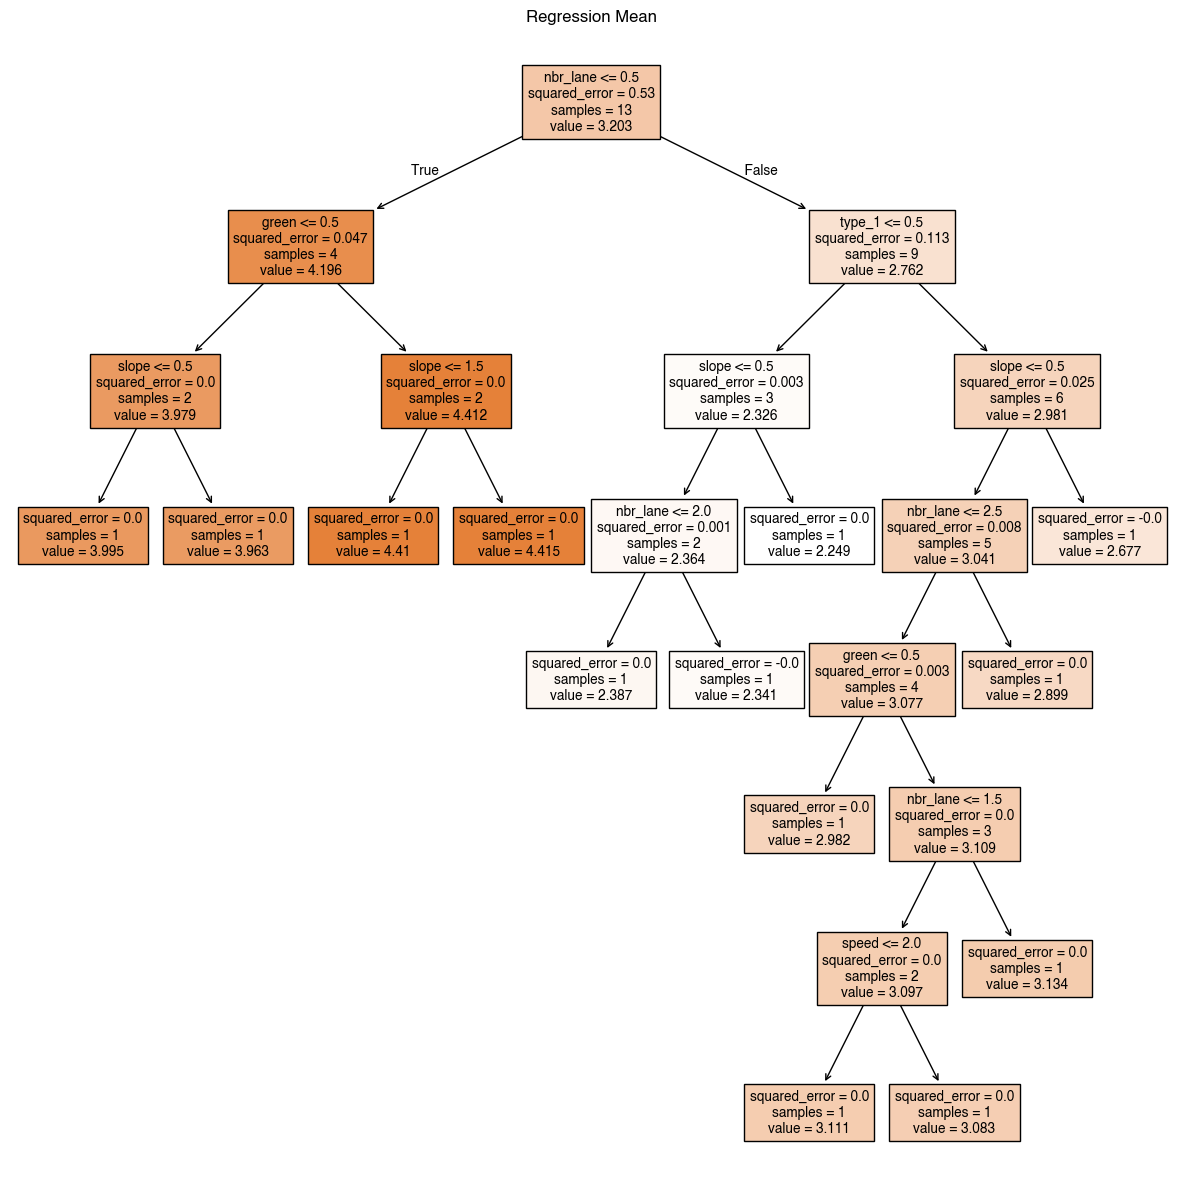

In [9]:
X_mean_train, X_mean_test, y_mean_train, y_mean_test = train_test_split(X_mean, y_mean, test_size=0.2, random_state=42)

regr_mean = DecisionTreeRegressor()
regr_mean.fit(X_mean_train, y_mean_train)

y_mean_predicted_train = regr_mean.predict(X_mean_train)
y_mean_predicted_test = regr_mean.predict(X_mean_test)

mse_mean_test = mean_squared_error(y_mean_test, y_mean_predicted_test)
mse_mean_train = mean_squared_error(y_mean_train, y_mean_predicted_train)
mae_mean_train = mean_absolute_error(y_mean_train, y_mean_predicted_train)
mae_mean_test = mean_absolute_error(y_mean_test, y_mean_predicted_test)
r2_mean_train = r2_score(y_mean_train, y_mean_predicted_train)
r2_mean_test = r2_score(y_mean_test, y_mean_predicted_test)
depth_mean = regr_mean.get_depth()

print("Regression Mean")
print(f"Train MSE: {mse_mean_train}, R²: {r2_mean_train}, mae: {mae_mean_train}")
print(f"Test MSE: {mse_mean_test}, R²: {r2_mean_test}, mae: {mae_mean_test}")
print(f"Depth: {depth_mean}")

plt.figure(figsize=(15, 15))
fig = plt.gcf()
fig.patch.set_alpha(0.4)
tree.plot_tree(regr_mean, feature_names=X_mean.columns, filled=True)
plt.title("Regression Mean")
plt.show()

In [10]:
liste_notes = [3.995,3.963,4.415,4.41,3.111,3.083,3.134,2.982,2.899,2.677,2.326,2.387,2.341]

In [11]:
max(liste_notes)

4.415

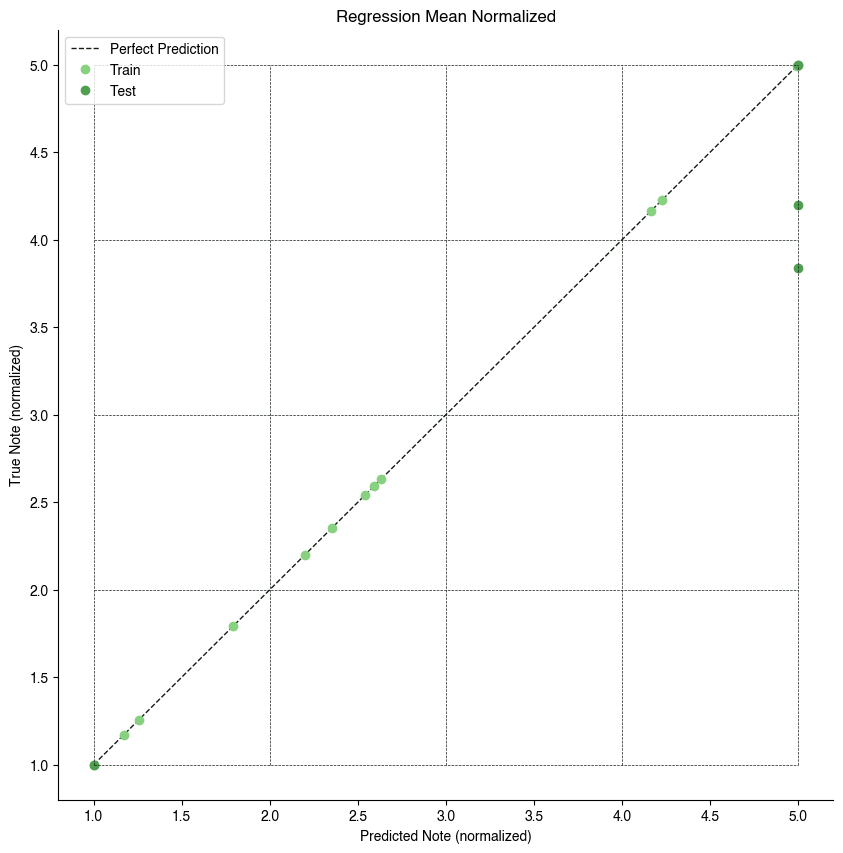

In [12]:
import numpy as np


# Normalisation min-max entre 1 et 5 puis arrondi à l'entier supérieur
def normalize_and_ceil(arr):
    arr = np.array(arr)
    norm = 1 + 4 * (arr - np.min(arr)) / (np.max(arr) - np.min(arr))
    return norm

y_mean_predicted_train_norm = normalize_and_ceil(y_mean_predicted_train)
y_mean_predicted_test_norm = normalize_and_ceil(y_mean_predicted_test)
y_mean_train_norm = normalize_and_ceil(y_mean_train)
y_mean_test_norm = normalize_and_ceil(y_mean_test)

fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(np.linspace(1, 5, 100), np.linspace(1, 5, 100), '--', color = noir, label='Perfect Prediction', linewidth=1)
ax.plot(y_mean_predicted_train_norm, y_mean_train_norm, 'o', color=cmap(1), label='Train')
ax.plot(y_mean_predicted_test_norm, y_mean_test_norm, 'o', color=cmap(0), label='Test')
ax.legend()
ax.set_xlabel("Predicted Note (normalized)")
ax.set_ylabel("True Note (normalized)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.vlines([1, 2, 3, 4,5], ymin=1, ymax=5, color=noir, linewidth=0.5, linestyles='--')
ax.hlines([1, 2, 3, 4,5], xmin=1, xmax=5, color=noir, linewidth=0.5, linestyles='--')
plt.title("Regression Mean Normalized")
plt.savefig("images/main/regression_mean_normalized.png")

In [13]:
import numpy as np

# Normalisation min-max entre 1 et 5
liste_notes_norm = 1 + 4 * (np.array(liste_notes) - np.min(liste_notes)) / (np.max(liste_notes) - np.min(liste_notes))
print(liste_notes_norm)

[4.19578746 4.13451412 5.         4.99042604 2.50311154 2.44949737
 2.54715175 2.2561034  2.09717568 1.67209191 1.         1.1168023
 1.02872188]


In [14]:
liste_notes_arrondi = [round(val) for val in liste_notes]
liste_notes_norm_arrondi = np.round(liste_notes_norm).astype(int)
print("Arrondi liste_notes:", liste_notes_arrondi)
print("Arrondi liste_notes_norm:", liste_notes_norm_arrondi)

Arrondi liste_notes: [4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 2, 2, 2]
Arrondi liste_notes_norm: [4 4 5 5 3 2 3 2 2 2 1 1 1]


### LOO Cross Validation (regr)

In [15]:
loo = LeaveOneOut()
y_true = []
y_pred = []

# Boucle Leave-One-Out
for train_index, test_index in loo.split(X_mean):
    X_train, X_test = X_mean.iloc[train_index], X_mean.iloc[test_index]
    y_train, y_test = y_mean.iloc[train_index], y_mean.iloc[test_index]

    regr = DecisionTreeRegressor()
    regr.fit(X_train, y_train)
    y_pred.append(regr.predict(X_test)[0])
    y_true.append(y_test.values[0])

# Évaluation globale
mse_loo = mean_squared_error(y_true, y_pred)
mae_loo = mean_absolute_error(y_true, y_pred)
r2_loo = r2_score(y_true, y_pred)

print("Leave-One-Out Cross-Validation (LOO)")
print(f"MSE: {mse_loo:.4f}")
print(f"MAE: {mae_loo:.4f}")
print(f"R²: {r2_loo:.4f}")


Leave-One-Out Cross-Validation (LOO)
MSE: 0.0354
MAE: 0.1523
R²: 0.9470


## 2 - classified mean (class_mean)

Classifier Mean
Train MSE: 0.0, accu: 1.0, f1: 1.0
Test MSE: 0.25, accu: 0.75, f1: 0.6
Depth: 2


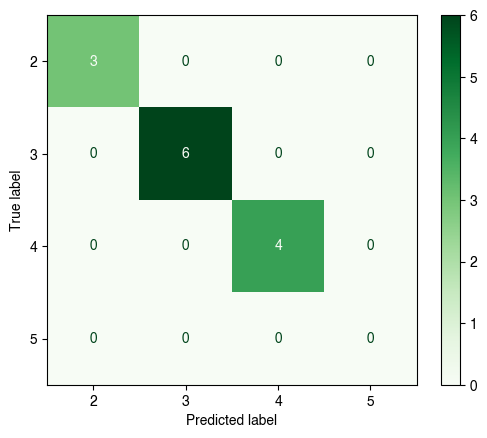

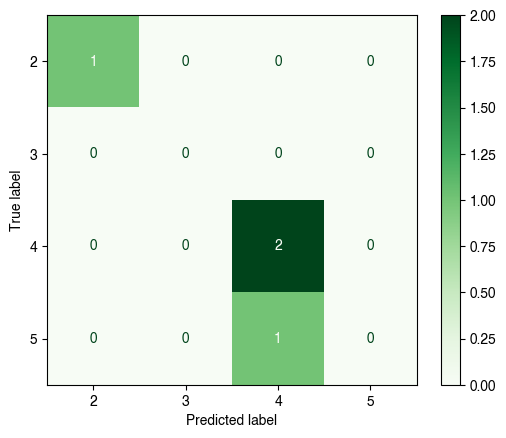

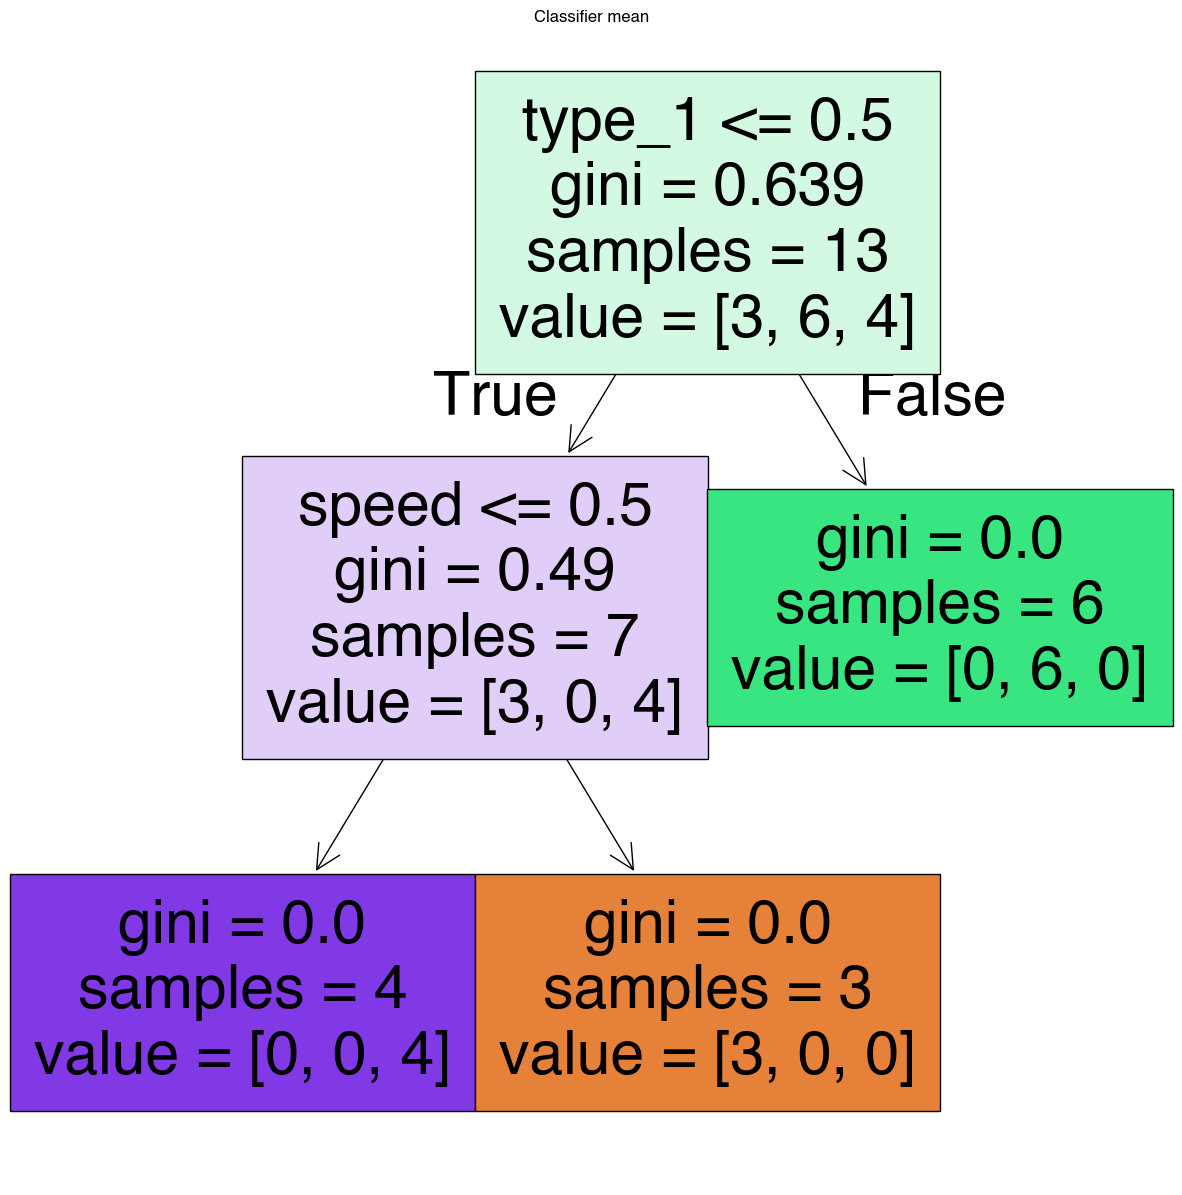

In [94]:
X_mean_c_train, X_mean_c_test, y_mean_c_train, y_mean_c_test = train_test_split(X_mean, y_mean_rounded, test_size=0.2, random_state=42)

class_mean = DecisionTreeClassifier()
class_mean.fit(X_mean_c_train, y_mean_c_train)

y_mean_c_predicted_train = class_mean.predict(X_mean_c_train)
y_mean_c_predicted_test = class_mean.predict(X_mean_c_test)

accu_mean_c_train = accuracy_score(y_mean_c_train, y_mean_c_predicted_train)
accu_mean_c_test = accuracy_score(y_mean_c_test, y_mean_c_predicted_test)
f1_mean_c_train = f1_score(y_mean_c_train, y_mean_c_predicted_train, average='macro')
f1_mean_c_test = f1_score(y_mean_c_test, y_mean_c_predicted_test, average='macro')
conf_matrix_mean_c_train = confusion_matrix(y_mean_c_train, y_mean_c_predicted_train, labels=[2,3,4,5])
conf_matrix_mean_c_test = confusion_matrix(y_mean_c_test, y_mean_c_predicted_test, labels=[2,3,4,5])
mse_mean_c_test = mean_squared_error(y_mean_c_test, y_mean_c_predicted_test)
mse_mean_c_train = mean_squared_error(y_mean_c_train, y_mean_c_predicted_train)

depth_mean_c = class_mean.get_depth()

print("Classifier Mean")
print(f"Train MSE: {mse_mean_c_train}, accu: {accu_mean_c_train}, f1: {f1_mean_c_train}")

print(f"Test MSE: {mse_mean_c_test}, accu: {accu_mean_c_test}, f1: {f1_mean_c_test}")

print(f"Depth: {depth_mean_c}")
ConfusionMatrixDisplay(conf_matrix_mean_c_train, display_labels=[2,3,4,5]).plot(cmap=plt.cm.Greens)
ConfusionMatrixDisplay(conf_matrix_mean_c_test, display_labels=[2,3,4,5]).plot(cmap=plt.cm.Greens)
plt.figure(figsize=(15, 15))
tree.plot_tree(class_mean, feature_names=X_mean.columns, filled=True)
plt.title("Classifier mean")
plt.show()

### LOO Cross Validation (class)

Leave-One-Out Classification
Accuracy: 0.8235
F1-score (macro): 0.6818
MSE: 0.0354


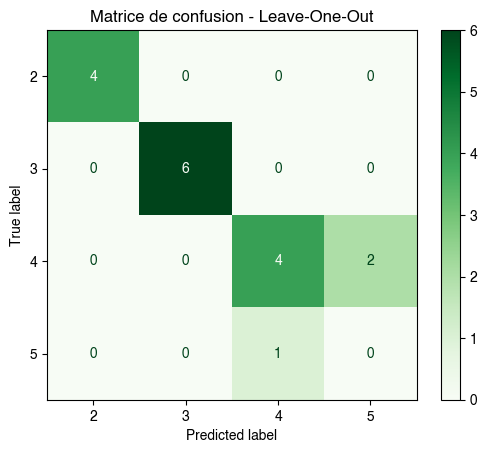

In [ ]:
loo = LeaveOneOut()
y_true_c = []
y_pred_c = []

# Boucle Leave-One-Out
for train_index, test_index in loo.split(X_mean):
    X_train, X_test = X_mean.iloc[train_index], X_mean.iloc[test_index]
    y_train, y_test = y_mean_rounded.iloc[train_index], y_mean_rounded.iloc[test_index]

    clf = DecisionTreeRegressor()
    clf.fit(X_train, y_train)
    y_pred_c.append(clf.predict(X_test)[0])
    y_true_c.append(y_test.values[0])

# Évaluation globale
accu_loo = accuracy_score(y_true_c, y_pred_c)
r2_loo = 
f1_loo = f1_score(y_true_c, y_pred_c, average='macro')
mse_loo_c = mean_squared_error(y_true_c, y_pred_c)
conf_matrix_loo = confusion_matrix(y_true_c, y_pred_c, labels=[2, 3, 4, 5])

print("Leave-One-Out Classification")
print(f"Accuracy: {accu_loo:.4f}")
print(f"F1-score (macro): {f1_loo:.4f}")
print(f"MSE: {mse_loo:.4f}")

# Affichage de la matrice de confusion globale
ConfusionMatrixDisplay(conf_matrix_loo, display_labels=[2, 3, 4, 5]).plot(cmap=plt.cm.Greens)
plt.title("Matrice de confusion - Leave-One-Out")
plt.show()

# All data tree

## 1 - data traitment

In [96]:
depth = None
random_state = 10

y_all = df_merged['note']

X_classified_df = df_merged[['nbr_lane', 'speed', 'slope', 'green']]
X_type = df_merged[['type']]

enc = OneHotEncoder(handle_unknown='ignore')
X_type_encoded = enc.fit_transform(X_type)

type_encoded_columns = enc.get_feature_names_out(['type'])

X_all_df = pd.concat([
    X_classified_df.reset_index(drop=True),
    pd.DataFrame(X_type_encoded.toarray(), columns=type_encoded_columns).reset_index(drop=True)
], axis=1)

In [97]:
X_all_df.describe()

,nbr_lane,speed,slope,green,type_0,type_1,type_2,type_3
count,3740.000000,3740.000000,3740.000000,3740.000000,3740.000000,3740.000000,3740.000000,3740.000000
mean,0.941176,1.352941,0.529412,0.764706,0.235294,0.352941,0.117647,0.294118
std,0.998402,1.280850,0.696102,0.644466,0.424239,0.477949,0.322233,0.455706
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,3.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000
max,3.000000,3.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


In [98]:
y_all.describe()

count    3740.000000
mean        3.310695
std         1.251794
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: note, dtype: float64

In [99]:
X_train, X_test, Y_train, Y_test = train_test_split(X_all_df, y_all, test_size=0.2, random_state=42)

## 2 - Regression (regr_all)

Regression All
Train MSE: 0.8970719187711476, R²: 0.4259913377085446, mae: 0.7429554444975904
Test MSE: 0.9171699380616667, R²: 0.41585969412757506, mae: 0.763268700248394
Depth: 7


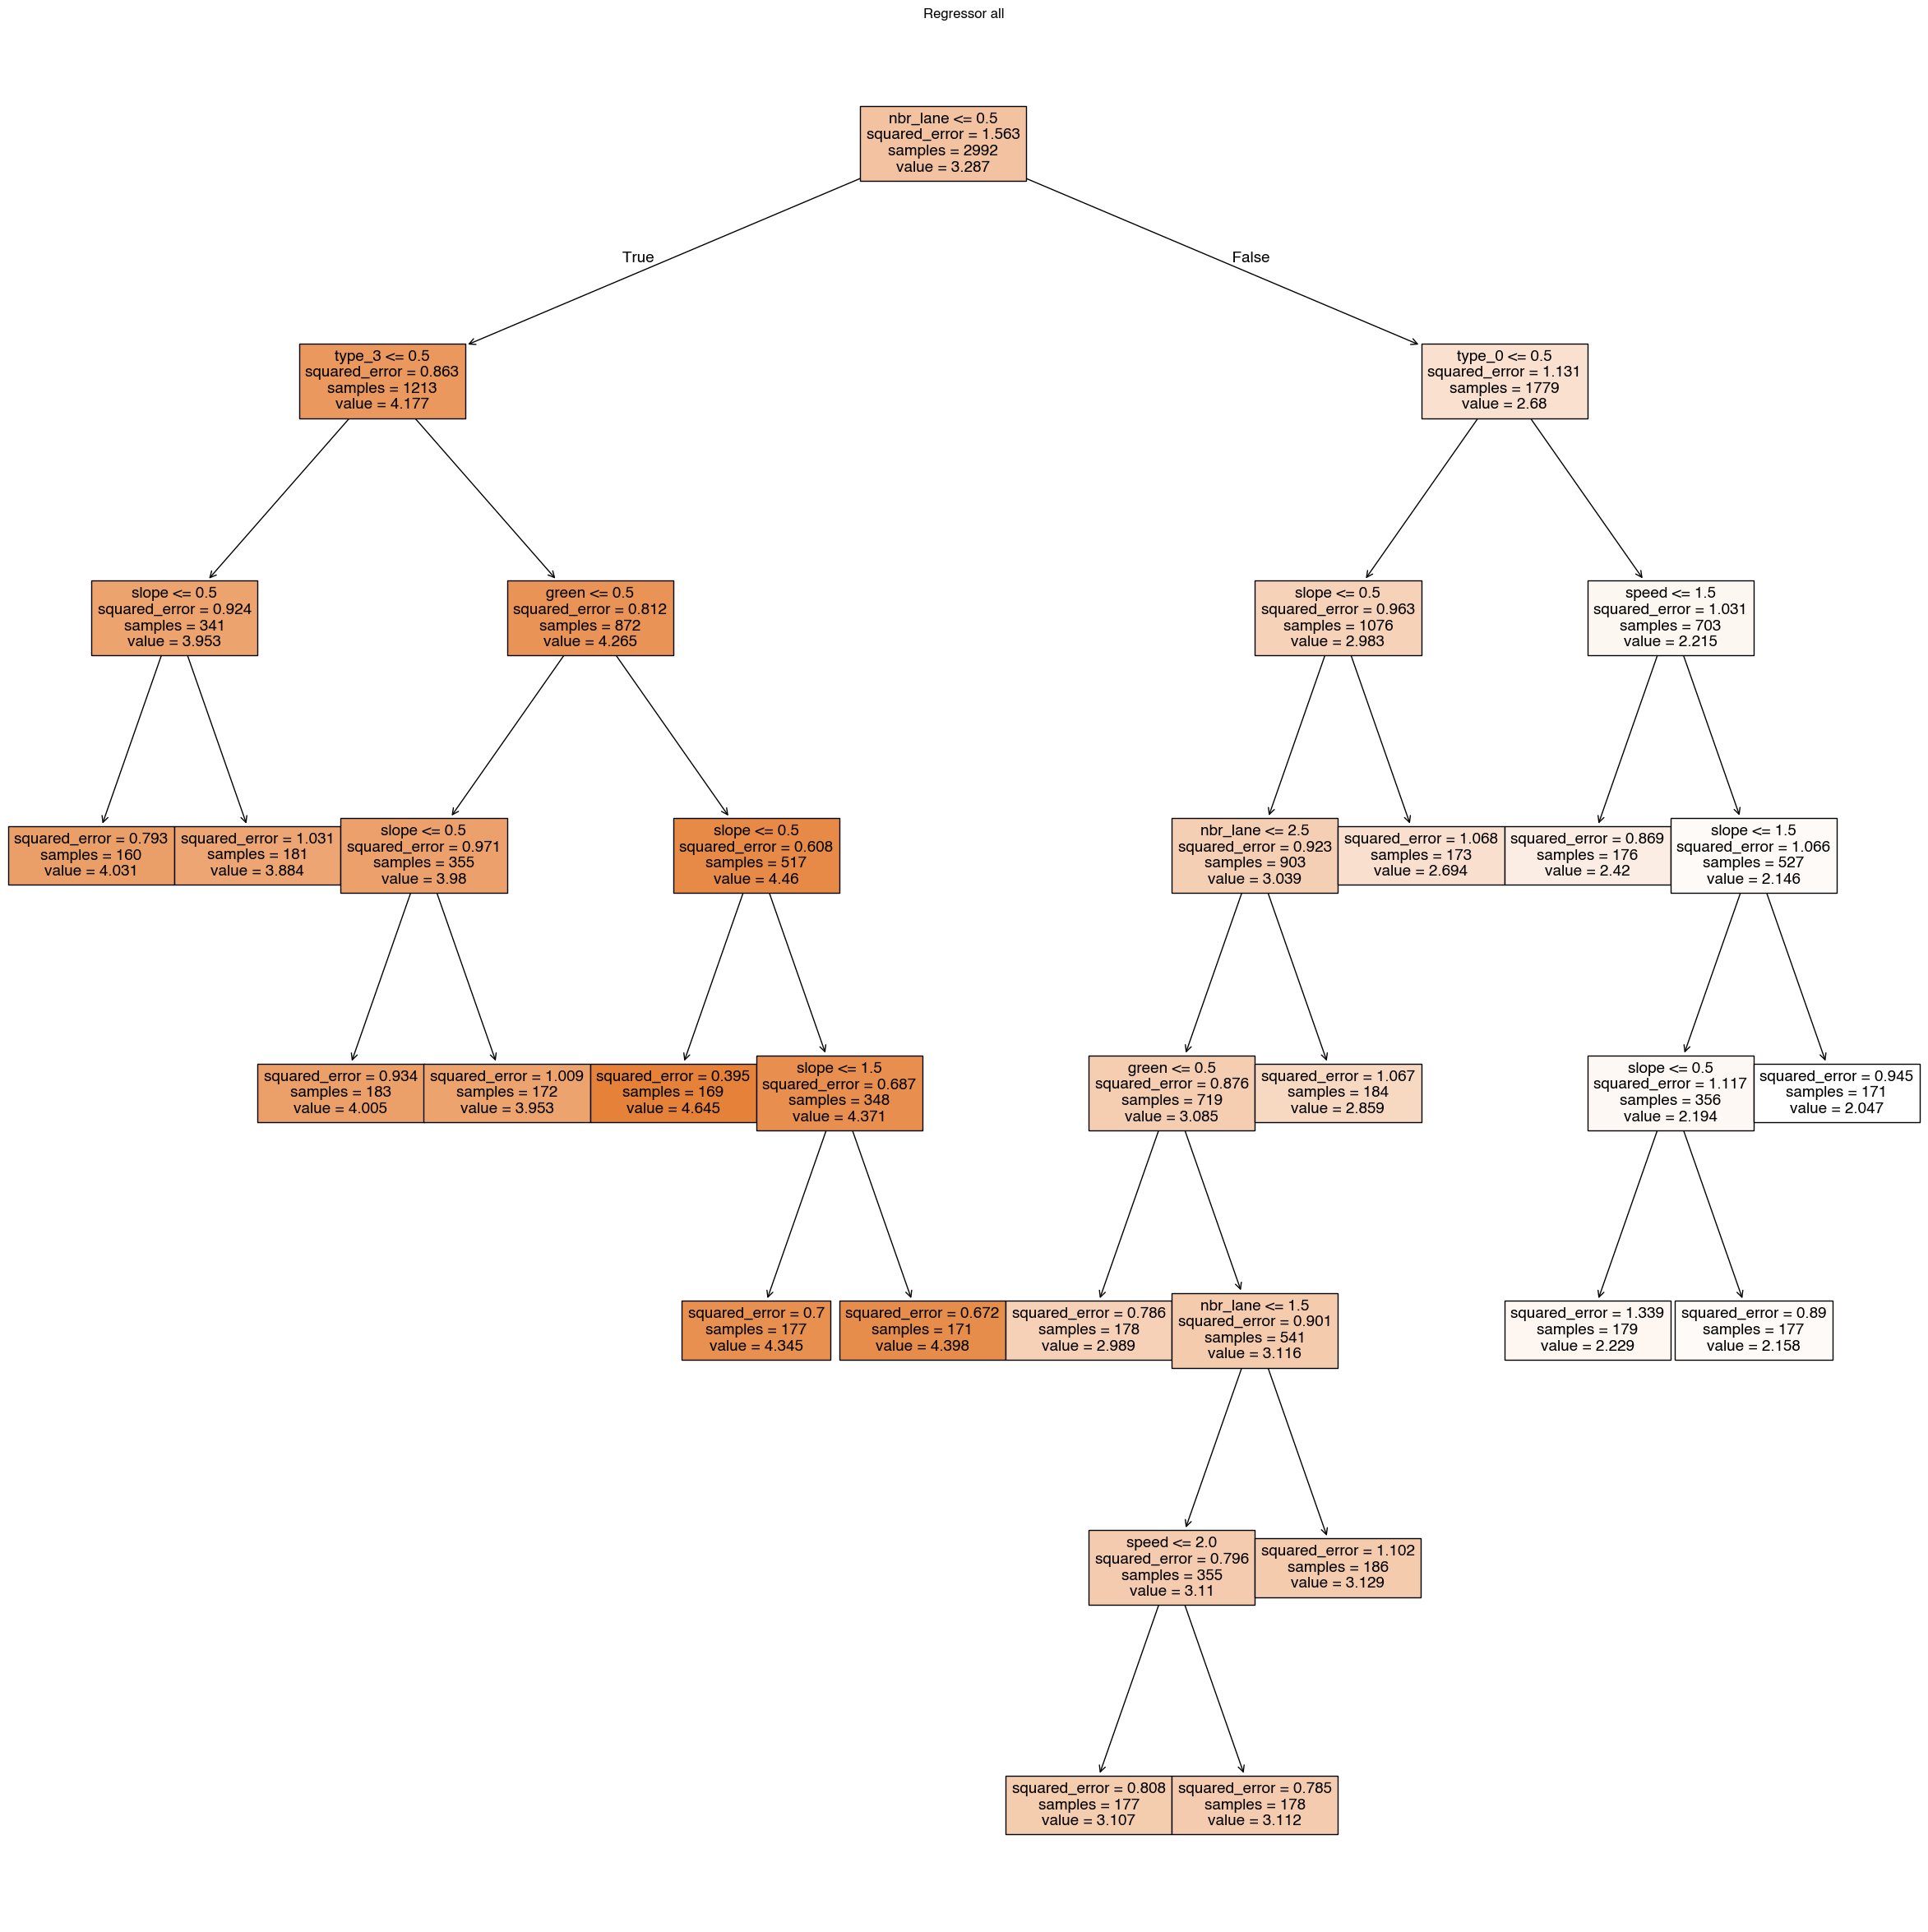

In [100]:
regr_all = DecisionTreeRegressor(max_depth=depth, random_state=random_state)

regr_all.fit(X_train, Y_train)

Y_all_predicted_test = regr_all.predict(X_test)
Y_all_predicted_train = regr_all.predict(X_train)

mse_all_test = mean_squared_error(Y_test, Y_all_predicted_test)
r2_all_test = r2_score(Y_test, Y_all_predicted_test)
mae_all_test = mean_absolute_error(Y_test, Y_all_predicted_test)

mse_all_train = mean_squared_error(Y_train, Y_all_predicted_train)
r2_all_train = r2_score(Y_train, Y_all_predicted_train)
mae_all_train = mean_absolute_error(Y_train, Y_all_predicted_train)

depth_all = regr_all.get_depth()

print("Regression All")
print(f"Train MSE: {mse_all_train}, R²: {r2_all_train}, mae: {mae_all_train}")
print(f"Test MSE: {mse_all_test}, R²: {r2_all_test}, mae: {mae_all_test}")
print(f"Depth: {depth_all}")


plt.figure(figsize=(30, 30))
tree.plot_tree(regr_all, filled=True,feature_names=X_all_df.columns)
plt.title("Regressor all")
plt.show()

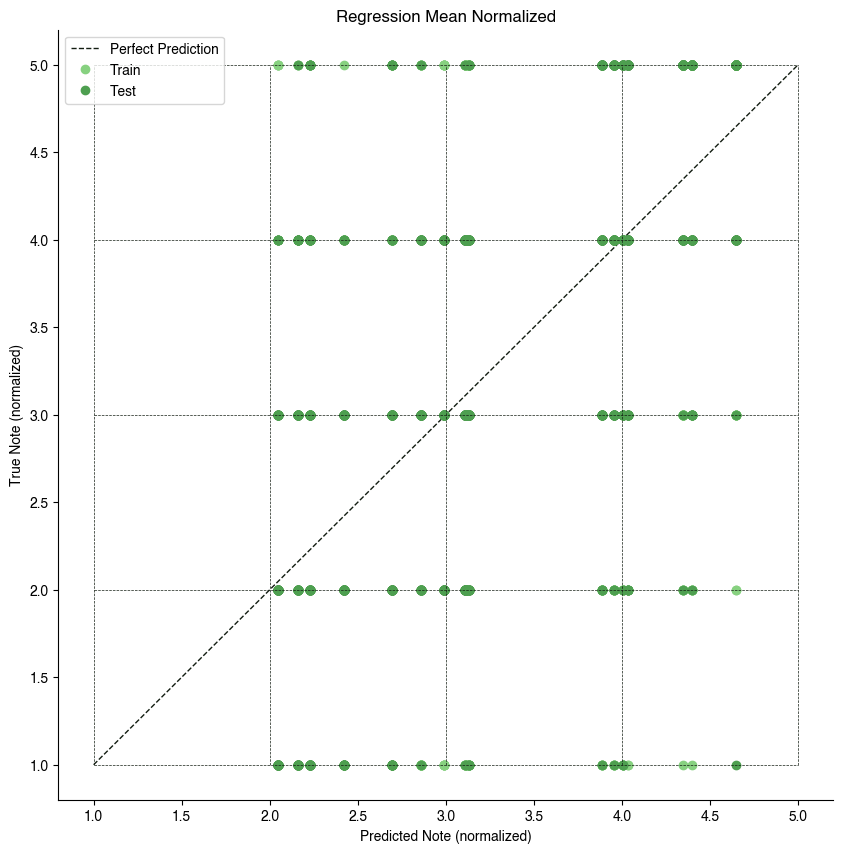

In [101]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(np.linspace(1, 5, 100), np.linspace(1, 5, 100), '--', color = noir, label='Perfect Prediction', linewidth=1)
ax.plot(Y_all_predicted_train, Y_train, 'o', color=cmap(1), label='Train')
ax.plot(Y_all_predicted_test, Y_test, 'o', color=cmap(0), label='Test')
ax.legend()
ax.set_xlabel("Predicted Note (normalized)")
ax.set_ylabel("True Note (normalized)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.vlines([1, 2, 3, 4,5], ymin=1, ymax=5, color=noir, linewidth=0.5, linestyles='--')
ax.hlines([1, 2, 3, 4,5], xmin=1, xmax=5, color=noir, linewidth=0.5, linestyles='--')
plt.title("Regression Mean Normalized")
plt.savefig("images/main/regression.png")

## 2 - Classifier (class_all)

Classifier all
Train MSE: 1.125668449197861, accu: 0.42613636363636365, f1: 0.40079677786082357, qwk: 0.6197358021903578
Test MSE: 1.2085561497326203, accu: 0.3997326203208556, f1: 0.35479067234884276, qwk: 0.5989618671208894
Depth: 6


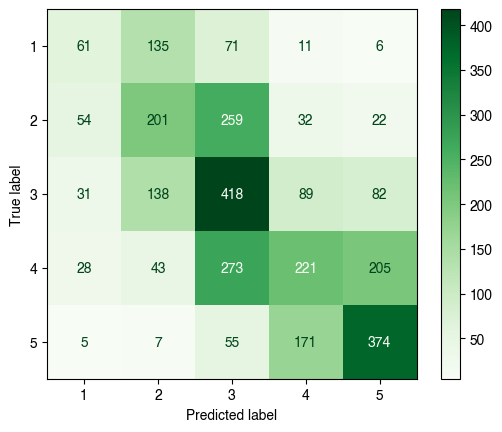

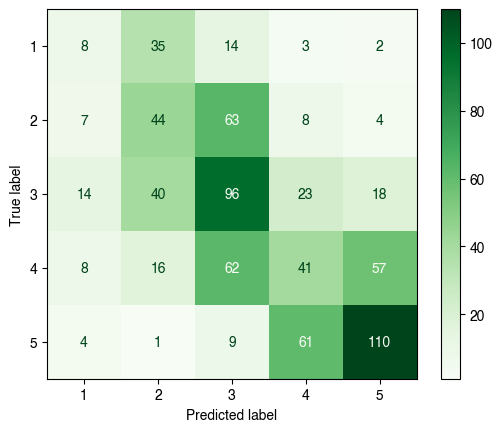

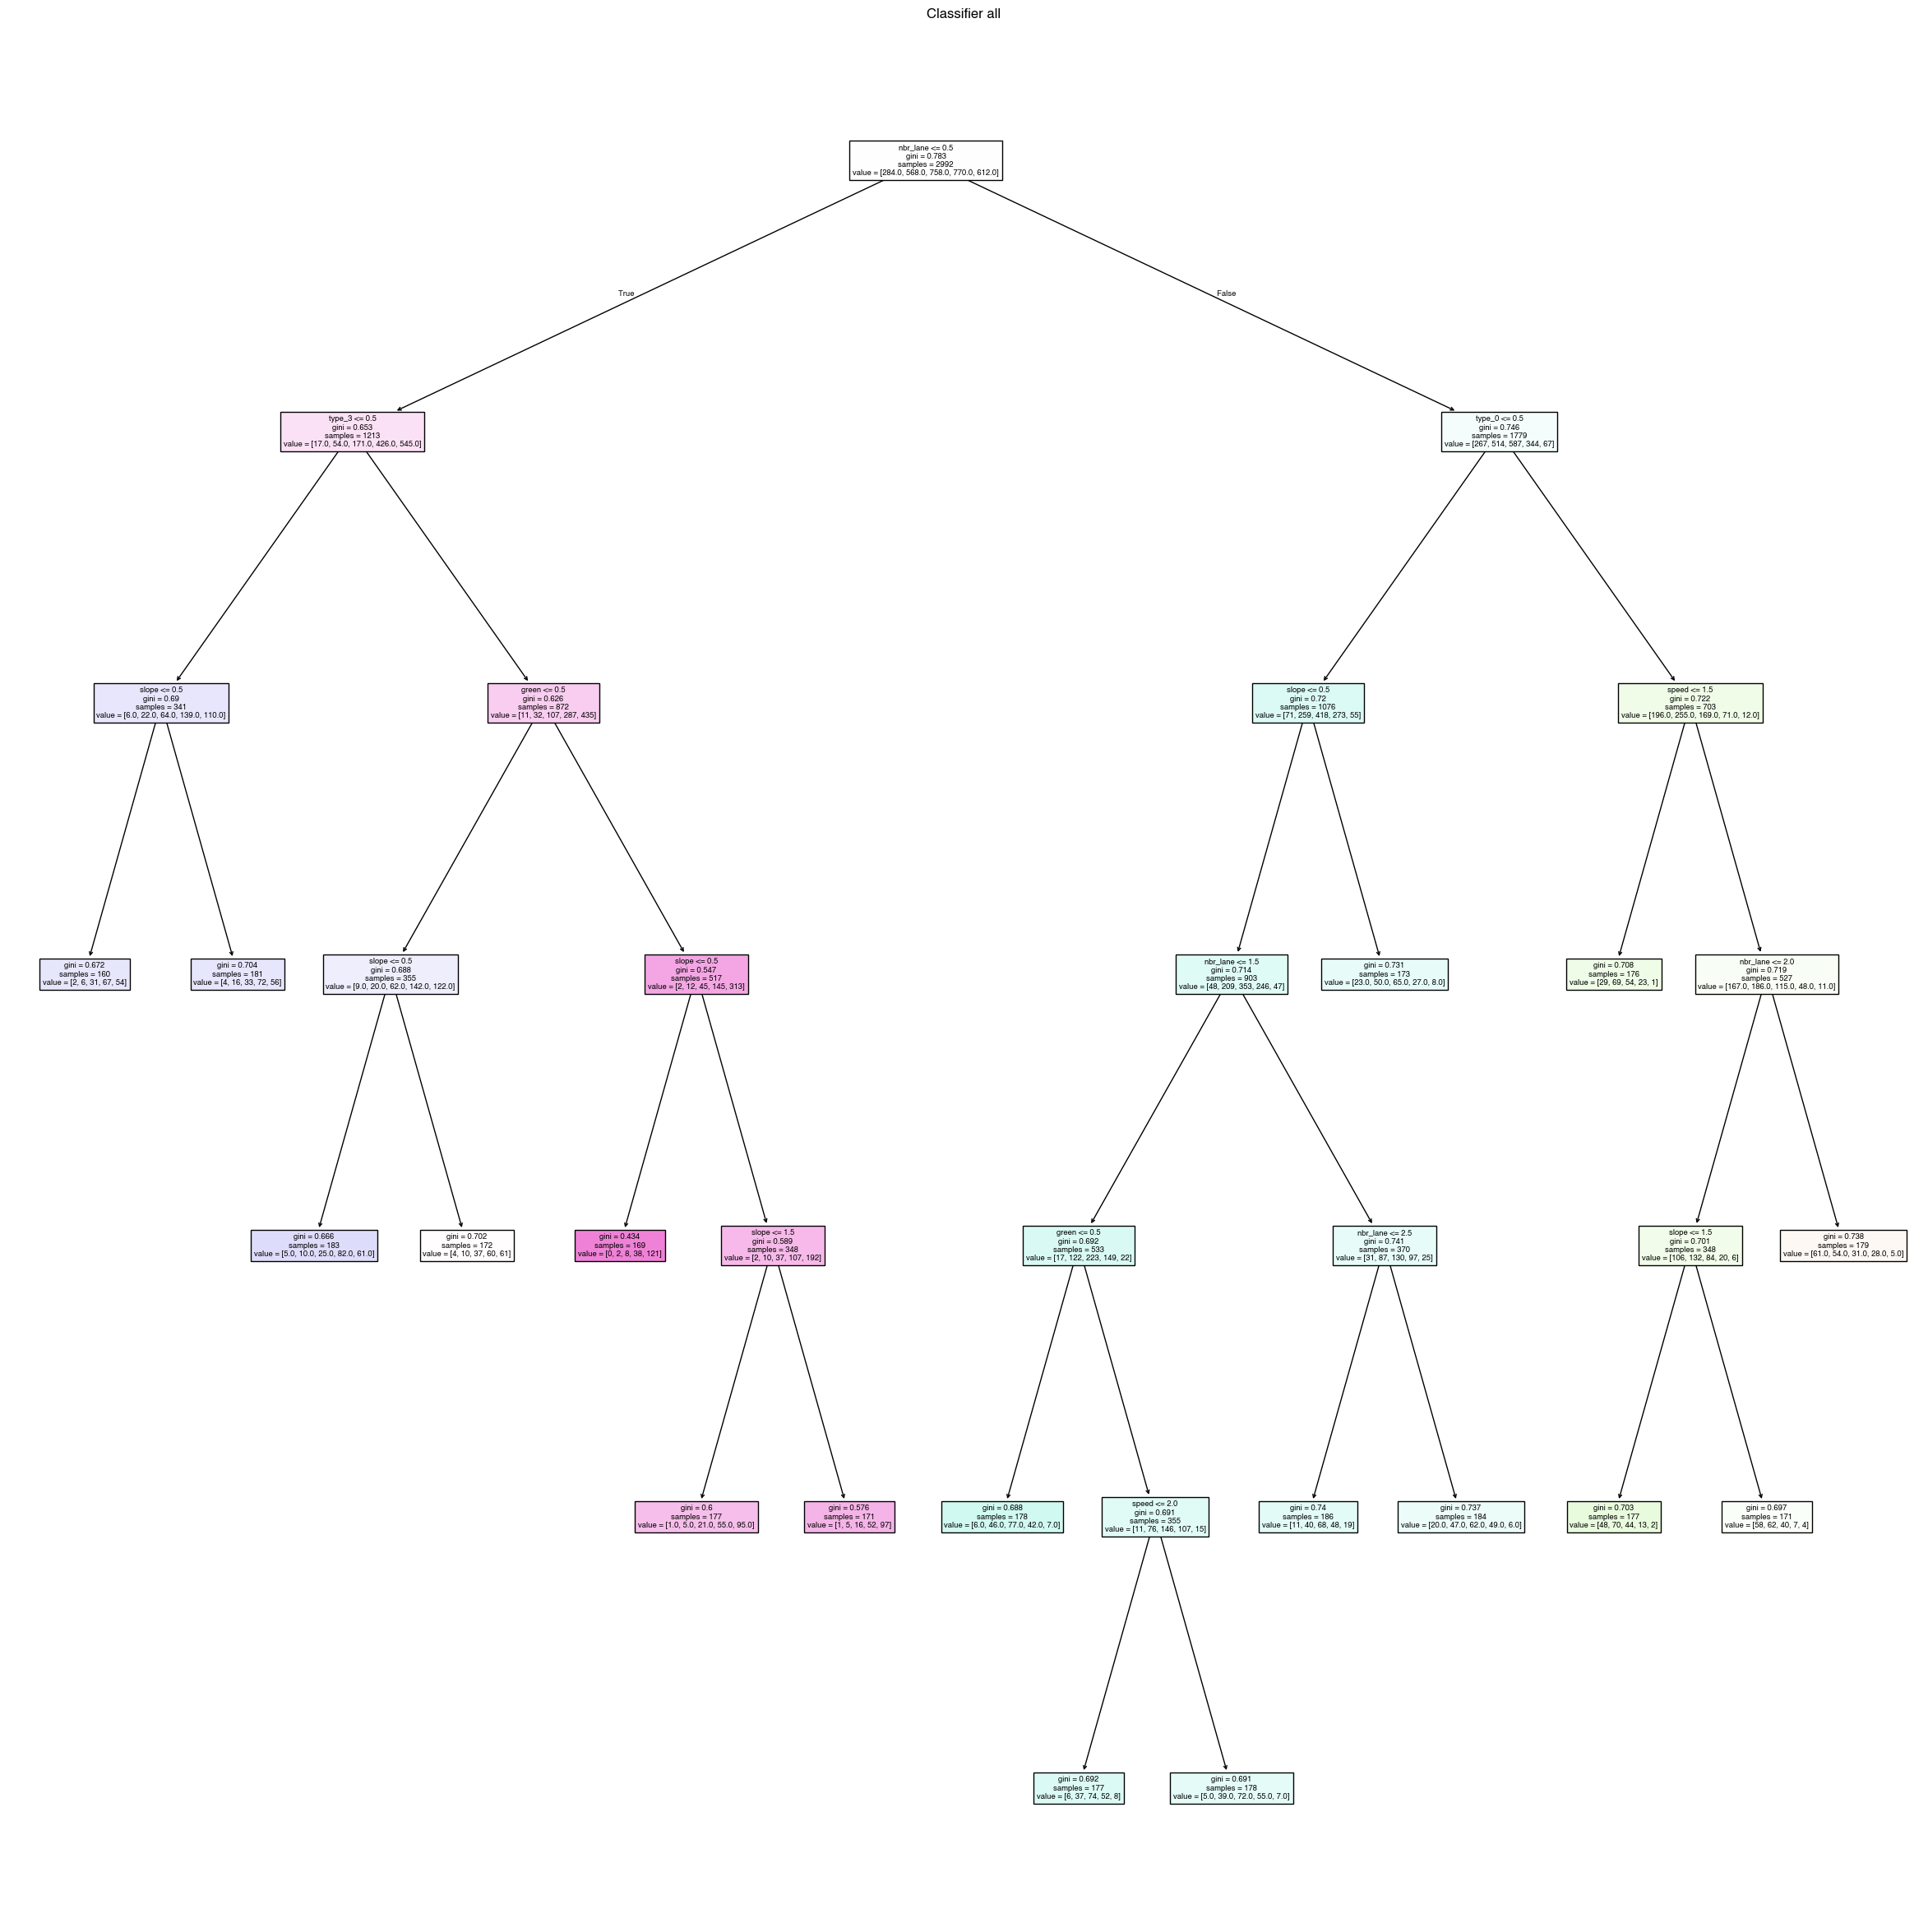

In [102]:
class_all = DecisionTreeClassifier(max_depth=None, random_state=42)

class_all.fit(X_train, Y_train)

Y_all_c_predicted_test = class_all.predict(X_test)
Y_all_c_predicted_train = class_all.predict(X_train)

accu_all_c_train = accuracy_score(Y_train, Y_all_c_predicted_train)
accu_all_c_test = accuracy_score(Y_test, Y_all_c_predicted_test)
f1_all_c_train = f1_score(Y_train, Y_all_c_predicted_train, average='macro')
f1_all_c_test = f1_score(Y_test, Y_all_c_predicted_test, average='macro')
conf_matrix_all_c_train = confusion_matrix(Y_train, Y_all_c_predicted_train, labels=[1,2,3,4,5])
conf_matrix_all_c_test = confusion_matrix(Y_test, Y_all_c_predicted_test, labels=[1,2,3,4,5])
mse_all_c_test = mean_squared_error(Y_test, Y_all_c_predicted_test)
mse_all_c_train = mean_squared_error(Y_train, Y_all_c_predicted_train)
qwk_all_c_train = cohen_kappa_score(Y_train, Y_all_c_predicted_train, weights='quadratic')
qwk_all_c_test = cohen_kappa_score(Y_test, Y_all_c_predicted_test, weights='quadratic')

depth_all_c = class_all.get_depth()
print("Classifier all")

print(f"Train MSE: {mse_all_c_train}, accu: {accu_all_c_train}, f1: {f1_all_c_train}, qwk: {qwk_all_c_train}")
print(f"Test MSE: {mse_all_c_test}, accu: {accu_all_c_test}, f1: {f1_all_c_test}, qwk: {qwk_all_c_test}")
print(f"Depth: {depth_all_c}")

ConfusionMatrixDisplay(conf_matrix_all_c_train, display_labels=[1,2,3,4,5]).plot(cmap=plt.cm.Greens)
ConfusionMatrixDisplay(conf_matrix_all_c_test, display_labels=[1,2,3,4,5]).plot(cmap=plt.cm.Greens)

plt.figure(figsize=(30, 30))
tree.plot_tree(class_all, filled=True,feature_names=X_all_df.columns)
plt.title("Classifier all")
plt.show()

In [103]:
joblib.dump(class_all, "biclac/models/class_all.pkl")

['biclac/models/class_all.pkl']

### QWK grid search

In [104]:
qwk_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# Définir les hyperparamètres à tester
param_grid = {
    'max_depth': [2, 4, 6, 8, 10, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

# Initialiser le classifieur
dt_clf = DecisionTreeClassifier(random_state=random_state)

# GridSearch avec QWK
grid_search = GridSearchCV(
    estimator=dt_clf,
    param_grid=param_grid,
    scoring=qwk_scorer,
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Lancer la recherche
grid_search.fit(X_train, Y_train)

# Meilleur modèle
best_clf = grid_search.best_estimator_
print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur QWK (CV) : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 63 candidates, totalling 315 fits
Meilleurs paramètres : {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Meilleur QWK (CV) : 0.6231



Évaluation du modèle optimisé (QWK)
Train - QWK: 0.6197, accu: 0.4261, f1: 0.4008
Test - QWK:  0.5990, accu: 0.3997, f1: 0.3548


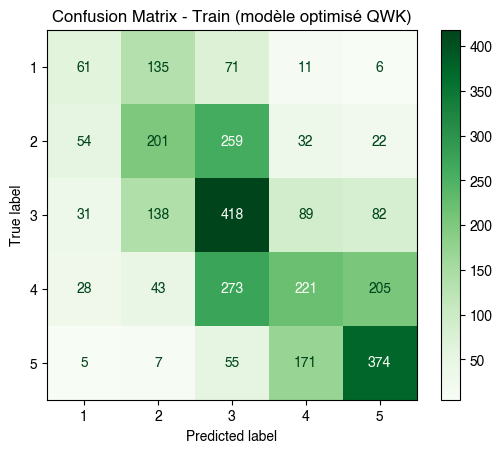

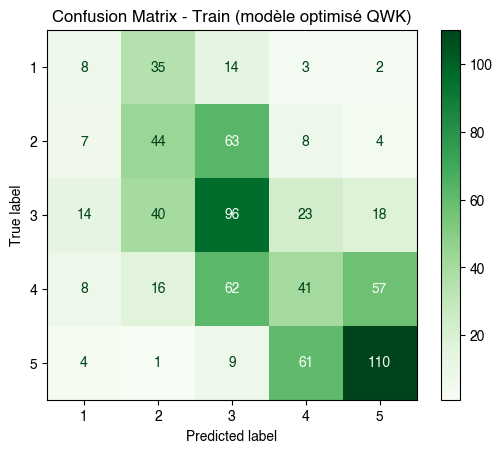

In [105]:
Y_pred_test = best_clf.predict(X_test)
Y_pred_train = best_clf.predict(X_train)

qwk_train = cohen_kappa_score(Y_train, Y_pred_train, weights='quadratic')
qwk_test = cohen_kappa_score(Y_test, Y_pred_test, weights='quadratic')
accu_all_c_opt_train = accuracy_score(Y_train, Y_pred_train)
accu_all_c_opt_test = accuracy_score(Y_test, Y_pred_test)
f1_all_c_opt_train = f1_score(Y_train, Y_pred_train, average='macro')
f1_all_c_opt_test = f1_score(Y_test, Y_pred_test, average='macro')
conf_matrix_train = confusion_matrix(Y_train, Y_pred_train, labels=[1,2,3,4,5])
conf_matrix_test = confusion_matrix(Y_test, Y_pred_test, labels=[1,2,3,4,5])

print("\nÉvaluation du modèle optimisé (QWK)")
print(f"Train - QWK: {qwk_train:.4f}, accu: {accu_all_c_opt_train:.4f}, f1: {f1_all_c_opt_train:.4f}")
print(f"Test - QWK:  {qwk_test:.4f}, accu: {accu_all_c_opt_test:.4f}, f1: {f1_all_c_opt_test:.4f}")

# Affichage - train
ConfusionMatrixDisplay(conf_matrix_train, display_labels=[1,2,3,4,5]).plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - Train (modèle optimisé QWK)")
plt.show()
# Affichage - train
ConfusionMatrixDisplay(conf_matrix_test, display_labels=[1,2,3,4,5]).plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - Train (modèle optimisé QWK)")
plt.show()

# Report

In [106]:
df_report = pd.DataFrame({
    "Model": ["linear_mean","linear_all","regr_mean", "class_mean", "regr_all", "class_all"],
    "Depth": [None, None, depth_mean, depth_mean_c, depth_all, depth_all_c],
    "MSE train": [mse_mean_lr_train, mse_all_lr_train, mse_mean_train, mse_mean_c_train, mse_all_train, mse_all_c_train],
    "MSE test": [mse_mean_lr_test, mse_all_lr_test, mse_mean_test, mse_mean_c_test, mse_all_test, mse_all_c_test],
    "R² train": [r2_mean_lr_train, r2_all_lr_train, r2_mean_train, None, r2_all_train, None],
    "R² test": [r2_mean_lr_test, r2_all_lr_test, r2_mean_test, None, r2_all_test, None],
    "MAE train": [None, None, mae_mean_train, None, mae_all_train, None],
    "MAE test": [None, None, mae_mean_test, None, mae_all_test, None],
    "Accuracy train": [None, None, None, accu_mean_c_train, None, accu_all_c_train],
    "Accuracy test": [None, None, None, accu_mean_c_test, None, accu_all_c_test],
    "F1 train": [None, None, None, f1_mean_c_train, None, f1_all_c_train],
    "F1 test": [None, None, None, f1_mean_c_test, None, f1_all_c_test],
    "LOO MSE": [None, None, mse_loo, mse_loo_c, None, None],
    "LOO MAE": [None, None, mae_loo, None, None, None],
    "LOO R²": [None, None, r2_loo, None, None, None],
    "LOO Accuracy": [None, None, None, accu_loo, None, None],
    "LOO F1": [None, None, None, f1_loo, None, None]
})
df_report= df_report.T

In [ ]:
print(df_report)

                          0           1          2           3         4  \
Model           linear_mean  linear_all  regr_mean  class_mean  regr_all   
Depth                   NaN         NaN        7.0         2.0       7.0   
MSE train          0.011305    0.910613        0.0         0.0  0.897072   
MSE test            0.02395    0.923644   0.119763        0.25   0.91717   
R² train           0.978688    0.417327        1.0         NaN  0.425991   
R² test            0.975068    0.411736   0.875329         NaN   0.41586   
MAE train               NaN         NaN        0.0         NaN  0.742955   
MAE test                NaN         NaN   0.320276         NaN  0.763269   
Accuracy train          NaN         NaN        NaN         1.0       NaN   
Accuracy test           NaN         NaN        NaN        0.75       NaN   
F1 train                NaN         NaN        NaN         1.0       NaN   
F1 test                 NaN         NaN        NaN         0.6       NaN   
LOO MSE     

: 